In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [2]:
#Load dataset
df = pd.read_csv('House_Price.csv')

In [3]:
#Summart stats
num_instances = df.shape[0]
num_features = df.shape[1]

#Identify categorical or numerical
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features = df.select_dtypes(exclude=['object']).columns.tolist()

summary_stats = {
    "Number of Instances": num_instances,
    "Number of Features": num_features,
    "Number of Categorical Features": len(categorical_features),
    "Number of Numerical Features": len(numerical_features)
}

summary_stats

{'Number of Instances': 1460,
 'Number of Features': 81,
 'Number of Categorical Features': 43,
 'Number of Numerical Features': 38}

In [4]:
#Make sure only numeric columns are selected
numeric_df = df.select_dtypes(include=['number'])

#Calcualte correlation with saleprice
correlation_matrix = numeric_df.corr()
saleprice_correlation = correlation_matrix["SalePrice"].sort_values(ascending=False)

#Get top 5
top_5_features = saleprice_correlation.index[1:6]
top_5 = saleprice_correlation[1:6]

top_5_features, top_5

(Index(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF'], dtype='object'),
 OverallQual    0.790982
 GrLivArea      0.708624
 GarageCars     0.640409
 GarageArea     0.623431
 TotalBsmtSF    0.613581
 Name: SalePrice, dtype: float64)

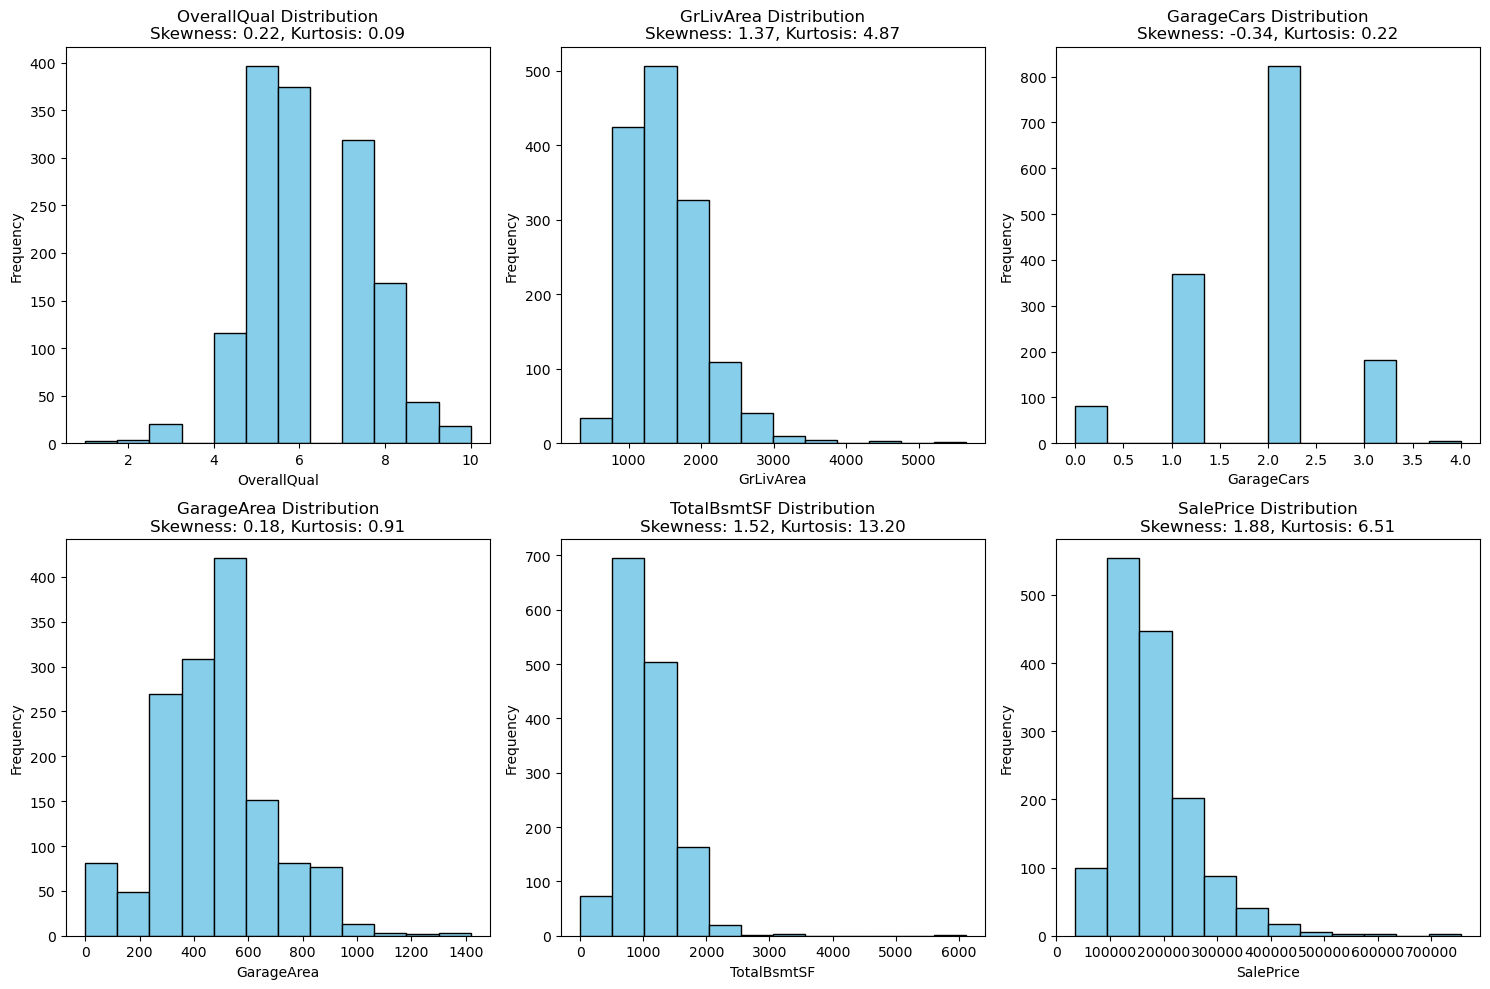

In [5]:
#Plot top 5 
plt.figure(figsize=(15, 10))

#go through top 5 and plot
for i, feature in enumerate(top_5_features.tolist() + ['SalePrice']):
    plt.subplot(2, 3, i + 1)
    data = df[feature].dropna()
    plt.hist(data, bins='sturges', edgecolor='black', color='skyblue')
    plt.title(f"{feature} Distribution\nSkewness: {skew(data):.2f}, Kurtosis: {kurtosis(data):.2f}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

OverallQual is slightly negatively skewed and the kurtosis shows a higher peak, indicating a leptokurtic distrubution. 

GrLivArea is positively skewed, with a few larger vales in the tail to the right. The kurtosis has a high peak, indicating leptokurtic distruburtion.

GarageCars is nearly symmetric and the kurtosis is a bit higher than normal.

GarageArea is positively skewed and the kurtosis has a higher peek suggesting a leptokurtic distrubution.

TotalBsmtSF is posivily skewed and the kurtosis has a higher peak.

SalePrice is positively skewed and kurtosis suggest leptokurtic distrubution.

In [7]:
#Check missing
missing_values = df.isnull().sum()
missing_features = missing_values[missing_values > 0]
missing_summary = {
    "Total Features with Missing Values": len(missing_features),
    "Missing Features": missing_features.index.tolist(),
    "Percentage Missing": (missing_features / num_instances * 100).tolist()
}

missing_summary

{'Total Features with Missing Values': 19,
 'Missing Features': ['LotFrontage',
  'Alley',
  'MasVnrType',
  'MasVnrArea',
  'BsmtQual',
  'BsmtCond',
  'BsmtExposure',
  'BsmtFinType1',
  'BsmtFinType2',
  'Electrical',
  'FireplaceQu',
  'GarageType',
  'GarageYrBlt',
  'GarageFinish',
  'GarageQual',
  'GarageCond',
  'PoolQC',
  'Fence',
  'MiscFeature'],
 'Percentage Missing': [17.73972602739726,
  93.76712328767123,
  59.726027397260275,
  0.547945205479452,
  2.5342465753424657,
  2.5342465753424657,
  2.6027397260273974,
  2.5342465753424657,
  2.6027397260273974,
  0.0684931506849315,
  47.26027397260274,
  5.5479452054794525,
  5.5479452054794525,
  5.5479452054794525,
  5.5479452054794525,
  5.5479452054794525,
  99.52054794520548,
  80.75342465753424,
  96.30136986301369]}

The total missing values is 19. Features with significant missing values are Alley with 93.8%, FireplaceQu with 47.3%, PoolQC with 99.5%, Fence with 80.8%, MiscFeature with 96.3%, and MasVnrType with 59.7%. These features have a decent proportion of missing values, partically Alley, PoolQC, Fence, and MiscFeature, which are all in the 80 - 100% range. These could impact the anaylsis if not handled properly.

(a)
“what factors affect the house price?”

Identify the key features that have the highest correlation with house prices. The includes determining the relative importance of various featres in pridicting house prices, which can be done through feature selection and imprtance ranking techniques.

“how do	
thes 	factor 	affec 	te 	hous pprice?”/“i 	whic 	wa 	do	the	factors	affec 	th 	hous 	price?”Develop a model to measure the correlation between the key factors indetified and the house prices. The involves creating a predictive model that can predict house pricews base on these features, allowing an understanding of how alteratiobns in each feature influence the price.

(b)
Regression: Regression is a method used for prediction that calculates the relationship between a dependent variable and on or more indepedent variables. Through the use of regression, we can directly quantify the effect of each feature on house prices. The method will allow use to adress the two business question by identifying key factors and understanding how they impact house prices.

Dimensionality reduction: Methods like Principal Component Analysis (PCA) and Linear Disceminant Anlysis (LDA) are effective in simplyifying complext datasets by recuing the number of features while retaining the most important information. This method can help identify the underlying structure of the data and the key factos that impact the flucuations in house prices. 


In [10]:
#Select features
features = df[['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', 'SalePrice', 'Neighborhood']]
#Remove missing values
features = features.dropna()
features.head()

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,SalePrice,Neighborhood
0,7,1710,2,548,856,208500,CollgCr
1,6,1262,2,460,1262,181500,Veenker
2,7,1786,2,608,920,223500,CollgCr
3,7,1717,3,642,756,140000,Crawfor
4,8,2198,3,836,1145,250000,NoRidge


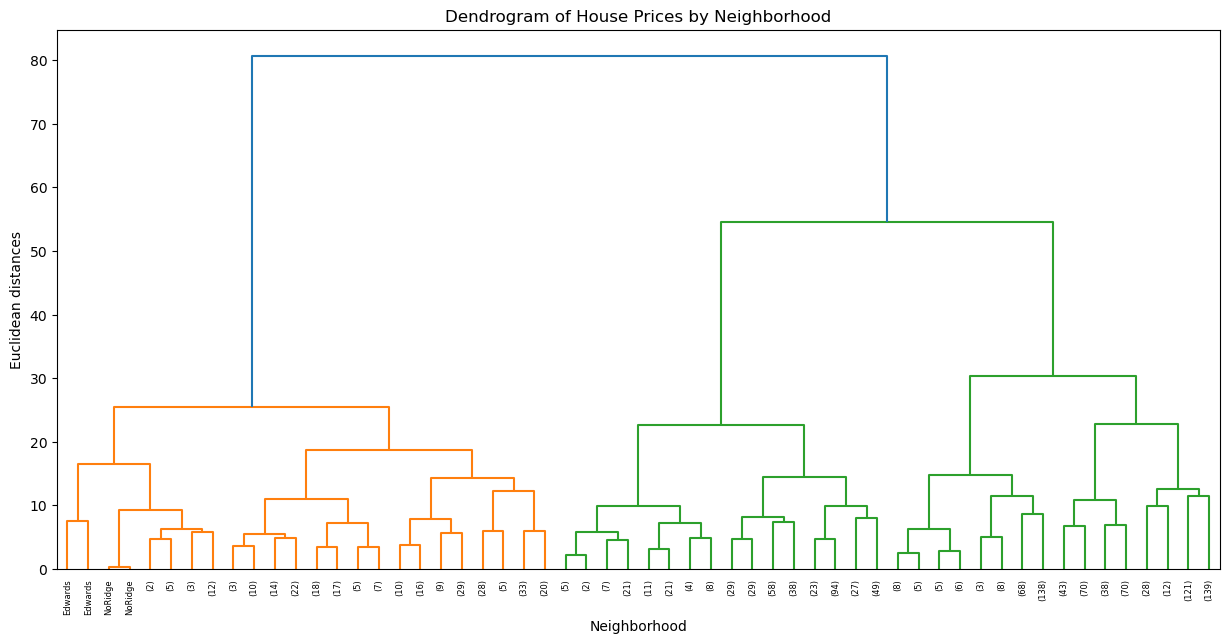

In [11]:
#Standardize
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features[['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', 'SalePrice']])

#convert to df
scaled_df = pd.DataFrame(scaled_features, columns=['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', 'SalePrice'])

#add neirboorhood back
scaled_df['Neighborhood'] = features['Neighborhood'].values

#hierarchical clustering
cluster = linkage(scaled_df[['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', 'SalePrice']], method='ward')
#plot
plt.figure(figsize=(15, 7))
dendrogram(cluster, labels=scaled_df['Neighborhood'].values, truncate_mode="level", p=5)
plt.title('Dendrogram of House Prices by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Euclidean distances')
plt.show()

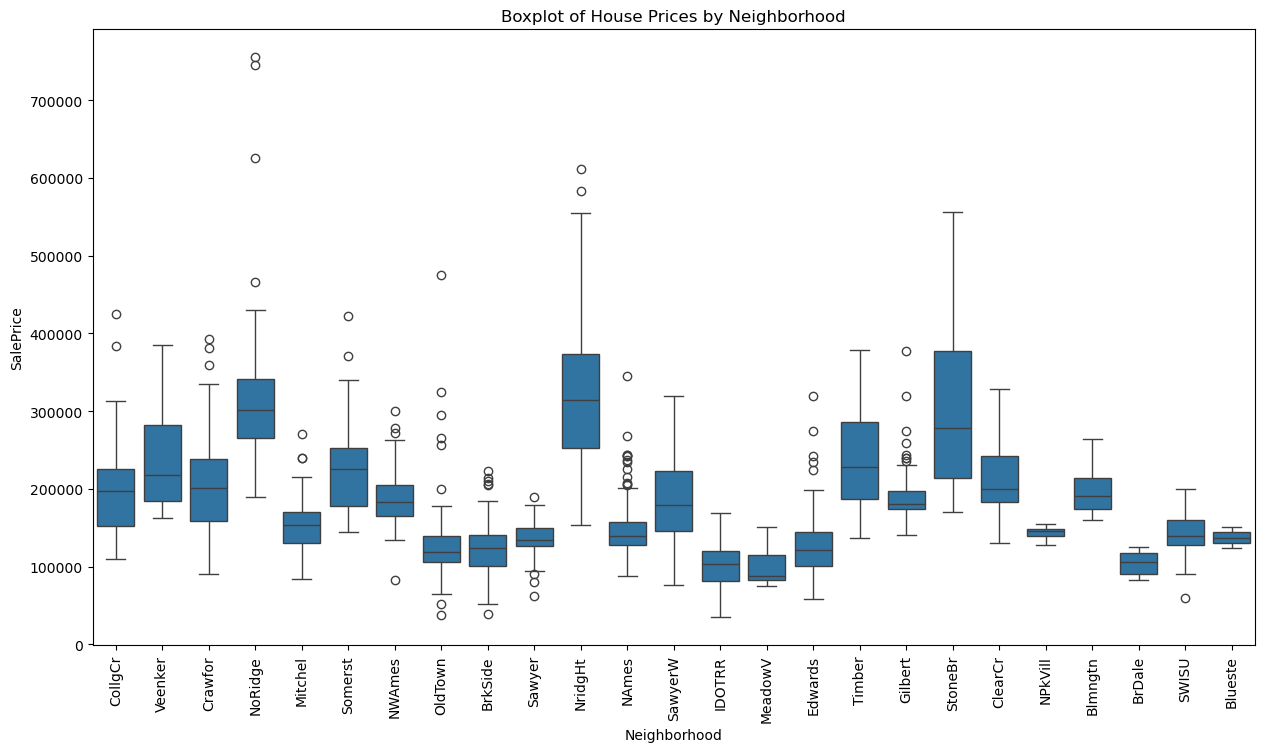

In [12]:
#boxplot visulatization
plt.figure(figsize=(15, 8))
sns.boxplot(x='Neighborhood', y='SalePrice', data=features)
plt.title('Boxplot of House Prices by Neighborhood')
plt.xticks(rotation=90)
plt.show()

The dendrogram shows that neighborhoods can be grouped baes on their house price. Some neightborhoods clustered together closer than others. The boxplot visually confirms the vartation in house price acorss the different neighborhoods, with some having a wide difference in median house prices. 

This concludes that, yes, house price does vary by neighborhood.

In [14]:
#split dataset
train_df, test_df = train_test_split(df, test_size=0.3, random_state=309)

#save splits
train_df.to_csv('train_data.csv', index=False)
test_df.to_csv('test_data.csv', index=False)

In [15]:
#define categorical and numerical
categorical_cols = train_df.select_dtypes(include=['object']).columns
numerical_cols = train_df.select_dtypes(exclude=['object']).columns

#pipeline
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

#fit and transform training data
train_processed = preprocessor.fit_transform(train_df)
test_processed = preprocessor.transform(test_df)

#convert back to dataframe
train_processed_df = pd.DataFrame(train_processed)
test_processed_df = pd.DataFrame(test_processed)

#save processed data
train_processed_df.to_csv('train_processed.csv', index=False)
test_processed_df.to_csv('test_processed.csv', index=False)

In [16]:
#convert to array
train_processed_array = train_processed.toarray()
test_processed_array = test_processed.toarray()

#dimensionality reduction PCA
pca = PCA(n_components=0.95)
pca_train = pca.fit_transform(train_processed_array)
pca_test = pca.transform(test_processed_array)

#dimensionality reduction RFE
model = LinearRegression()
rfe = RFE(model, n_features_to_select=10)
rfe_train = rfe.fit_transform(train_processed_array, train_df['SalePrice'])
rfe_test = rfe.transform(test_processed_array)

#save reduced data
pd.DataFrame(pca_train).to_csv('pca_train.csv', index=False)
pd.DataFrame(pca_test).to_csv('pca_test.csv', index=False)
pd.DataFrame(rfe_train).to_csv('rfe_train.csv', index=False)
pd.DataFrame(rfe_test).to_csv('rfe_test.csv', index=False)

In [17]:
X_train, y_train = rfe_train, train_df['SalePrice']
X_test, y_test = rfe_test, test_df['SalePrice']

#linear regression
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
y_pred_train_linear = linear_reg.predict(X_train)
y_pred_test_linear = linear_reg.predict(X_test)
mse_train_linear = mean_squared_error(y_train, y_pred_train_linear)
mse_test_linear = mean_squared_error(y_test, y_pred_test_linear)

#ridge regression
ridge_reg = Ridge(alpha=0.5)
ridge_reg.fit(X_train, y_train)
y_pred_train_ridge = ridge_reg.predict(X_train)
y_pred_test_ridge = ridge_reg.predict(X_test)
mse_train_ridge = mean_squared_error(y_train, y_pred_train_ridge)
mse_test_ridge = mean_squared_error(y_test, y_pred_test_ridge)

#results
print(f"Linear Regression - Train MSE: {mse_train_linear}, Test MSE: {mse_test_linear}")
print(f"Ridge Regression - Train MSE: {mse_train_ridge}, Test MSE: {mse_test_ridge}")

Linear Regression - Train MSE: 9.444168722077057e-21, Test MSE: 1.5575350130561953e-20
Ridge Regression - Train MSE: 3837.769572045004, Test MSE: 3228.6621131706347


Both MSE's for linear regression are very low, which suggests that the linear regression moedle may be overfitting. Given the values are near-zero, this could be an issue with the scale of predictions.

The ridge reggresion model shows a more reasonable performance, with both the train and test MSE's being within a reasonable range. The MSE on the test set being lower compared to the training set could suggest that the ridge model is regulairzinig the model paramters effectivly.

In [19]:
#random forest regression
random_reg = RandomForestRegressor(random_state=309)
random_reg.fit(X_train, y_train)
y_pred_train_rf = random_reg.predict(X_train)
y_pred_test_rf = random_reg.predict(X_test)
mse_train_rf = mean_squared_error(y_train, y_pred_train_rf)
mse_test_rf = mean_squared_error(y_test, y_pred_test_rf)

# Report results
print(f"Random Forest Regression - Train MSE: {mse_train_rf}, Test MSE: {mse_test_rf}")

Random Forest Regression - Train MSE: 1761059.2026906055, Test MSE: 24022833.110121027


The random forest regression model shows a much higher MSE on both the training and test sets. This suggests that it may not be a very good model for this problem or it could require furthur tuning to make it fit better. The large difference between the train MSE and test MSE suggests possible overfitting or that the model struggles to generalize well to the test set.